In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


x = np.linspace(0, 10, 11)  # 11 points evenly spaced: 0,1,...,10
y = np.array([0, 2, 1, 3, 0, 4, -1, 2, 3, 1, 0])  # Some arbitrary values

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 3)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 3)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    
    A = h[1:-1]              # sub-diagonal
    B = 2*(h[:-1] + h[1:]) # main diagonal
    C = h[1:-1]              # super-diagonal
    D = 6 * ((y[2:] - y[1:-1])/h[1:] - (y[1:-1] - y[:-2])/h[:-1]) #RHS vector
    
      
    return A, B, C, D

In [3]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

I stole these 2 functions from Charlie's slides and modified them a little bit. They should work.

In [4]:
A,B,C,D = setup_tridiagonal_matrix(x, y)

print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)
M_interior = thomas_algorithm(A,B,C,D) #curvature at interior points x_2 to x_n-1
print("Second Derivatives:", M_interior)

M = np.zeros(len(x)) #curvature of all the full data set
M[1:-1] = M_interior

Subdiagonal (A): [1. 1. 1. 1. 1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4. 4. 4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1. 1. 1. 1. 1.]
Right-hand side (D): [-18.  18. -30.  42. -54.  48. -12. -18.   6.]
Second Derivatives: [ -7.00208834  10.00835338 -15.03132517  20.11694732 -23.43646409
  19.62890904  -7.07917206  -3.31222078   2.3280552 ]


In [5]:
def evaluate_spline(x_data, y_data, M, x_query):
    
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S


Also stole this from Charlie's slides

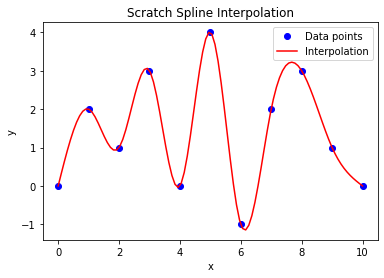

In [6]:
# Generate new x values for a smooth plot
x_interp = np.linspace(0, 10, 100)
y_eval = evaluate_spline(x,y,M, x_interp)


#Plots data and the "from_scratch" spline
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_interp, y_eval, 'r-',
label="Interpolation")
plt.title("Scratch Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

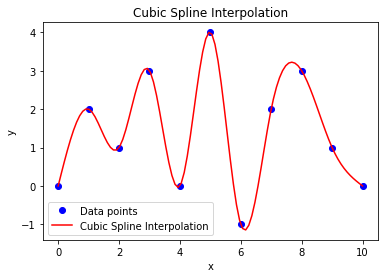

In [8]:
#Scipy's Natural Cubic Spline
# Create a cubic spline interpolation of the data
cs = CubicSpline(x, y, bc_type='natural')

y_interp = cs(x_interp)

# Plot the original data and cubic spline interpolation
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_interp, y_interp, 'r-',
label="Cubic Spline Interpolation")
plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Yippee it work!!!!!